In [5]:
import time
from deepface import DeepFace
import os, pickle
import numpy as np
from pathlib import Path

In [3]:
# Step 2: Time one image first

test_img = "../datasets/images/Tejrit.jpg"
for det in ["opencv", "yunet", "mtcnn"]:
    t = time.time()
    DeepFace.represent(test_img, model_name="Facenet512",
                       detector_backend=det, enforce_detection=False)
    print(det, round(time.time() - t, 2), "s")

opencv 3.36 s
yunet 0.31 s
mtcnn 12.95 s


In [14]:
import os, pickle
from pathlib import Path
from deepface import DeepFace

DATABASE_DIR = "../datasets/raw_data/"
CACHE_PATH = Path("../datasets/results/index_deepface_v2.pkl")
MODEL, DETECTOR = "Facenet512", "yunet"
EXTS = (".jpg", ".jpeg", ".png")
MIN_FACE_PX = 40          # ignore faces smaller than this (width or height)
MIN_CONF = 0.90           # ignore low-confidence detections

CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)

def save_index(index):
    tmp = CACHE_PATH.with_suffix(".tmp")
    with open(tmp, "wb") as f:
        pickle.dump(index, f)
    tmp.replace(CACHE_PATH)

index = {}
if CACHE_PATH.exists():
    with open(CACHE_PATH, "rb") as f:
        index = pickle.load(f)

all_paths = [os.path.join(r, f)
             for r, _, fs in os.walk(DATABASE_DIR)
             for f in fs if f.lower().endswith(EXTS)]
todo = [p for p in all_paths if p not in index]
print(f"{len(all_paths)} images, {len(todo)} left")

for n, path in enumerate(todo, 1):
    faces = []
    try:
        reps = DeepFace.represent(path, model_name=MODEL,
                                  detector_backend=DETECTOR,
                                  enforce_detection=True, align=True)
        for r in reps:
            fa = r["facial_area"]
            conf = r.get("face_confidence", 1.0)
            if fa["w"] < MIN_FACE_PX or fa["h"] < MIN_FACE_PX or conf < MIN_CONF:
                continue
            faces.append({"emb": r["embedding"],
                          "box": (fa["x"], fa["y"], fa["w"], fa["h"]),
                          "conf": conf})
    except Exception:
        pass
    index[path] = faces
    if n % 25 == 0:
        save_index(index)
        print(f"{n}/{len(todo)}")

save_index(index)
print("Done ->", CACHE_PATH.resolve())

513 images, 513 left
25/513
50/513
75/513
100/513
125/513
150/513
175/513
200/513
225/513
250/513
275/513
300/513
325/513
350/513
375/513
400/513
425/513
450/513
475/513
500/513
Done -> /home/rakesh/GitRepo/Object-Detection-Models/datasets/results/index_deepface_v2.pkl


#### **Step 4: Search the index (instant)**

In [15]:
import pickle
import numpy as np
from pathlib import Path
from deepface import DeepFace

QUERY_IMAGE = "../datasets/images/Tejrit.jpg"
CACHE_PATH = Path("../datasets/results/index_deepface_v2.pkl")
MODEL, DETECTOR = "Facenet512", "yunet"

STRICT_THRESHOLD = 0.30   # confident matches
TOP_K = 12                # always show the closest K for inspection
QUERY_FACE_IDX = None     # set to 0, 1, ... to force a face if the photo has several

def unit(v):
    v = np.asarray(v, dtype=np.float32)
    return v / np.linalg.norm(v, axis=-1, keepdims=True)

# --- Load index
with open(CACHE_PATH, "rb") as f:
    index = pickle.load(f)

paths, boxes, vecs = [], [], []
for p, faces in index.items():
    for fc in faces:
        paths.append(p); boxes.append(fc["box"]); vecs.append(fc["emb"])
vecs = unit(np.array(vecs))
print(f"{len(vecs)} faces indexed from {len(index)} images")

# --- Detect faces in the raw query image (must find a real face)
q_reps = DeepFace.represent(QUERY_IMAGE, model_name=MODEL,
                            detector_backend=DETECTOR,
                            enforce_detection=True, align=True)
print(f"{len(q_reps)} face(s) found in query image")

if QUERY_FACE_IDX is None:
    # pick the largest face
    q_rep = max(q_reps, key=lambda r: r["facial_area"]["w"] * r["facial_area"]["h"])
else:
    q_rep = q_reps[QUERY_FACE_IDX]
q = unit(q_rep["embedding"])
qa = q_rep["facial_area"]
q_box = (qa["x"], qa["y"], qa["w"], qa["h"])

# --- Rank, keeping the best face per image
dist = 1 - vecs @ q
order = np.argsort(dist)

seen, matches = set(), []
for i in order:
    if paths[i] in seen:
        continue
    seen.add(paths[i])
    matches.append((paths[i], float(dist[i]), boxes[i]))
    if len(matches) >= TOP_K:
        break

strict = [m for m in matches if m[1] < STRICT_THRESHOLD]
print(f"{len(strict)} strict matches (< {STRICT_THRESHOLD}); showing top {len(matches)}")

298 faces indexed from 513 images
1 face(s) found in query image
12 strict matches (< 0.3); showing top 12


#### **Step 5: Plot the results**

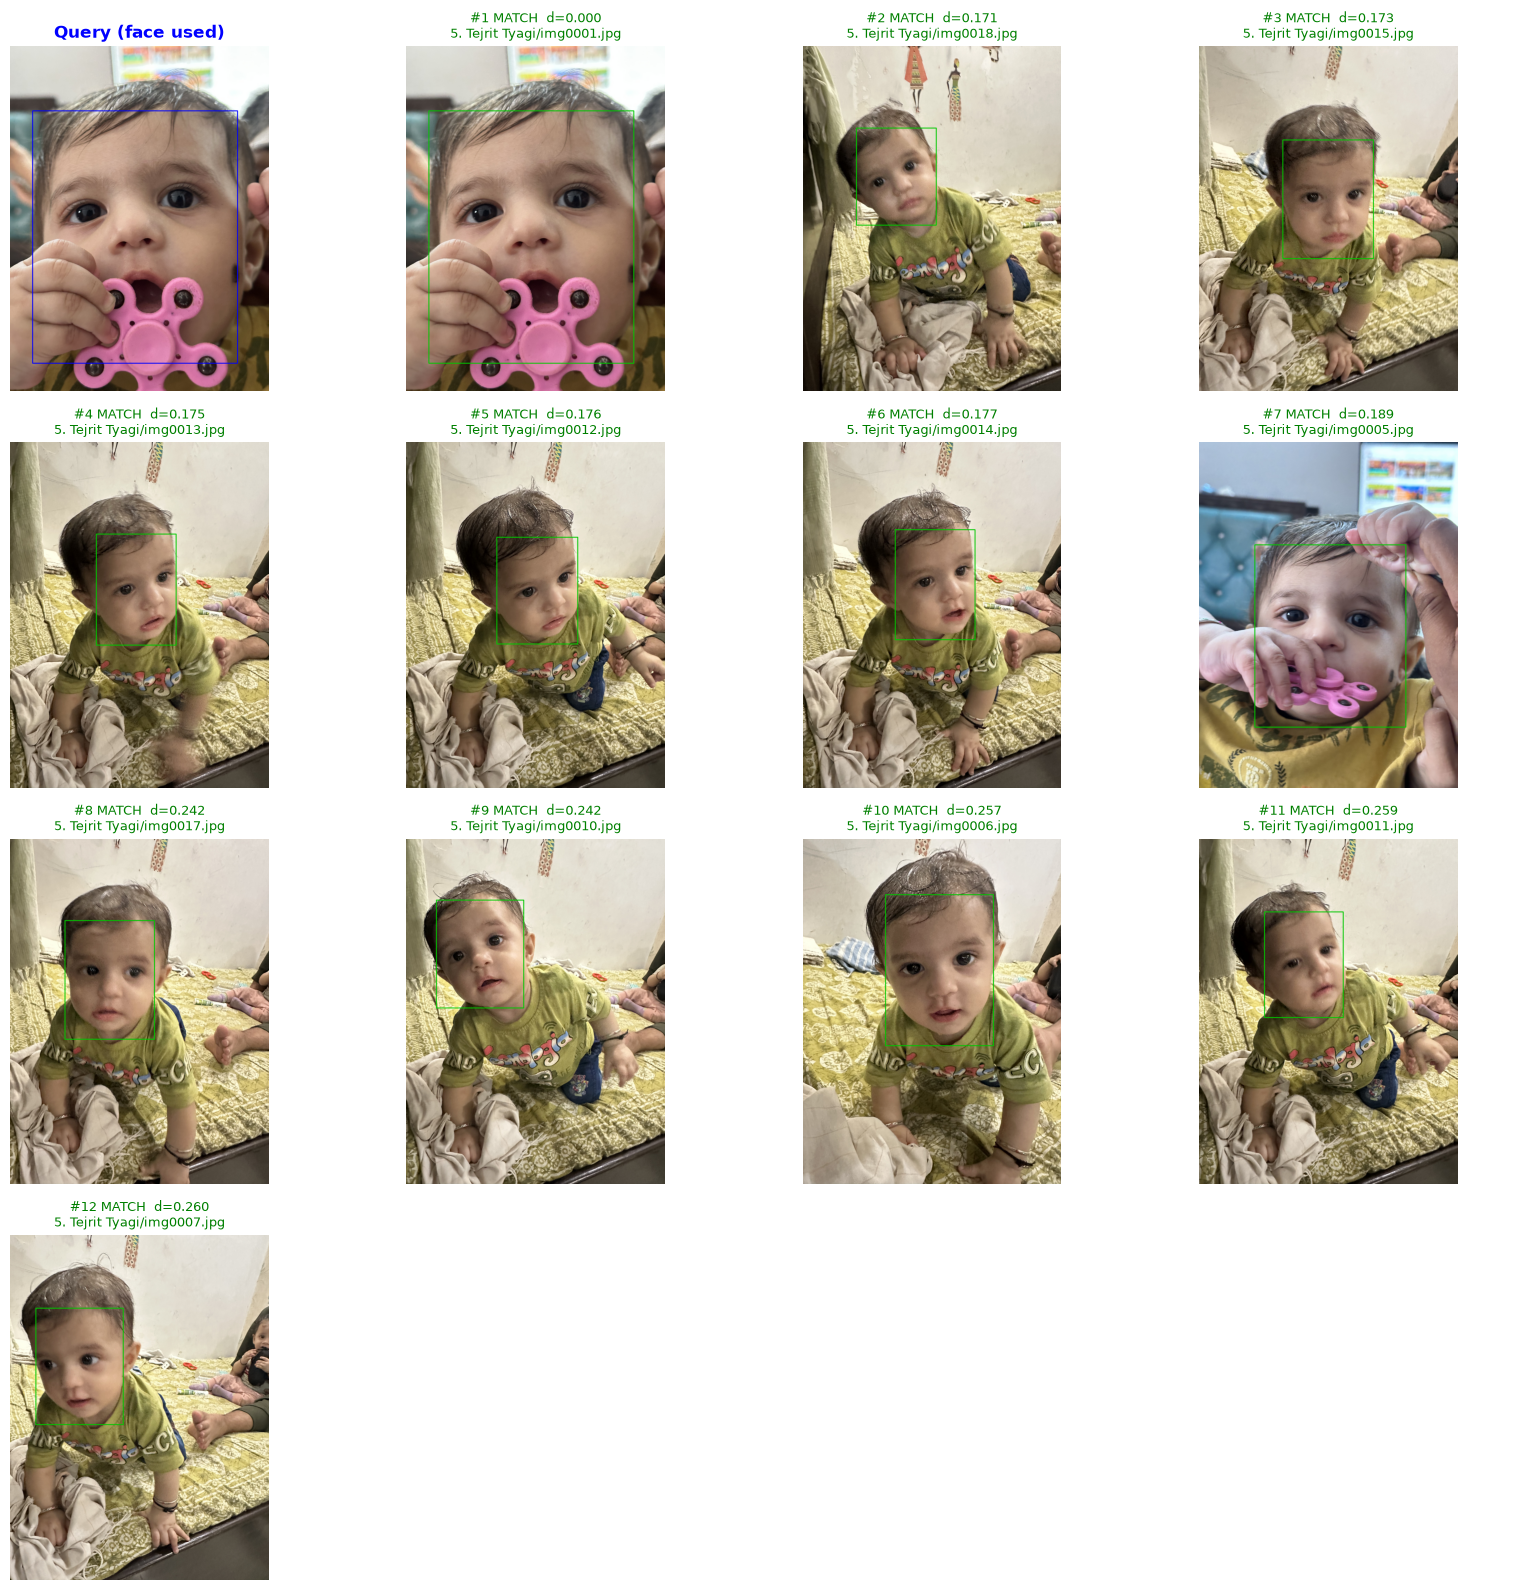

In [16]:
import math, os, cv2
import matplotlib.pyplot as plt

def load_with_box(path, box, color):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    x, y, w, h = box
    t = max(2, img.shape[1] // 300)
    cv2.rectangle(img, (x, y), (x + w, y + h), color, t)
    return img

cols = 4
rows = math.ceil((1 + len(matches)) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = axes.flatten()

axes[0].imshow(load_with_box(QUERY_IMAGE, q_box, (0, 0, 255)))
axes[0].set_title("Query (face used)", color="blue", fontweight="bold")

for i, (path, d, box) in enumerate(matches, 1):
    good = d < STRICT_THRESHOLD
    axes[i].imshow(load_with_box(path, box, (0, 200, 0) if good else (255, 0, 0)))
    axes[i].set_title(f"#{i} {'MATCH' if good else 'weak'}  d={d:.3f}\n"
                      f"{os.path.basename(os.path.dirname(path))}/{os.path.basename(path)[:18]}",
                      fontsize=9, color="green" if good else "red")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()